In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
from pathlib import Path
import re
import json

In [2]:
# read all results.json files from outputs
all_results = list(Path("../outputs").glob("**/results.json"))
datasets_name = ["gigaspeech","spgispeech_2"]
filtered_results = [result for result in all_results if any(dataset in str(result) for dataset in datasets_name)]
all_train_logs = list(Path("../outputs").glob("**/*.log"))
filtered_train_logs = [log for log in all_train_logs if any(dataset in str(log) for dataset in datasets_name)]


In [3]:
metadata = {
    "000": {"Lora Rank": 0,"Type": "base"},
    "001": {"Lora Rank": 0,"Type": "standard"},
    "002": {"Lora Rank": 8,"Type": "lora"},
    "0021": {"Lora Rank": 16,"Type": "lora"},
    "0022": {"Lora Rank": 32,"Type": "lora"},
    "0023": {"Lora Rank": 64,"Type": "lora"},
    "0024": {"Lora Rank": 128,"Type": "lora"},
    "0025": {"Lora Rank": 256,"Type": "lora"},
    "0026": {"Lora Rank": 512,"Type": "lora"},
}

In [4]:
# metdadata to dataframe 
df_metadata = pd.DataFrame.from_dict(metadata,orient='index').reset_index()
df_metadata.columns = ['run_name','Lora Rank','Type']
gigaspeech_logs = [log for log in all_train_logs if "gigaspeech" in str(log)]
gigaspeech_dict = {}
for log in gigaspeech_logs:
    run_name = str(log).split("/")[3]
    trainable_parameters = 0
    
    with open(log, "r") as f:
        for line in f:
            # Case-insensitive check
            if "trainable params" in line.lower():
                match = re.search(r"trainable params:\s*([\d,]+)", line, re.IGNORECASE)
                if match:
                    # Remove commas and convert to int
                    trainable_parameters = int(match.group(1).replace(",", ""))
                    break
    
    gigaspeech_dict[run_name] = {
        "all_parameters": 816967680, 
        "trainable_parameters": trainable_parameters
    }
df_gigaspeech = pd.DataFrame.from_dict(gigaspeech_dict,orient='index').reset_index()
df_gigaspeech.columns = ['run_name','all_parameters','Trainable Parameters']

df_metadata = pd.merge(df_metadata,df_gigaspeech,on='run_name')
df_metadata['Trainable Parameters (%)'] = df_metadata['Trainable Parameters'].astype(int)/df_metadata['all_parameters'].astype(int)*100
df_metadata

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%)
0,000,0,base,816967680,0,0.000000
1,001,0,standard,816967680,53109760,6.500840
2,002,8,lora,816967680,423112,0.051791
3,0021,16,lora,816967680,846224,0.103581
4,0022,32,lora,816967680,1692448,0.207162
5,0023,64,lora,816967680,3384896,0.414324
6,0024,128,lora,816967680,6769792,0.828649
7,0025,256,lora,816967680,13539584,1.657297
8,0026,512,lora,816967680,27079168,3.314595


In [5]:
# reading wer from results.json into a results dictionary incuding run_name and wer
gigaspeech_results = [res for res in all_results if "gigaspeech" in str(res)]
results_dict = {}
for res in gigaspeech_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_gigaspeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_gigaspeech_results.columns = ['run_name','wer']
df_gigaspeech_results['Dataset'] = 'GigaSpeech'
df_gigaspeech_results

,run_name,wer,Dataset
0,0022,0.140357,GigaSpeech
1,0023,0.137062,GigaSpeech
2,0021,0.159421,GigaSpeech
3,000,0.149531,GigaSpeech
4,0024,0.133787,GigaSpeech
5,002,0.162545,GigaSpeech
6,0026,0.167381,GigaSpeech
7,001,0.135231,GigaSpeech
8,0025,0.135291,GigaSpeech


In [6]:
df_total_gigaspeech = pd.merge(df_metadata,df_gigaspeech_results, on="run_name", how="inner")
df_total_gigaspeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech
2,002,8,lora,816967680,423112,0.051791,0.162545,GigaSpeech
3,0021,16,lora,816967680,846224,0.103581,0.159421,GigaSpeech
4,0022,32,lora,816967680,1692448,0.207162,0.140357,GigaSpeech
5,0023,64,lora,816967680,3384896,0.414324,0.137062,GigaSpeech
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech


In [7]:
spgispeech_2_results = [res for res in all_results if "spgispeech_2" in str(res)]
results_dict = {}
for res in spgispeech_2_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_spgispeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_spgispeech_results.columns = ['run_name','wer']
df_spgispeech_results['Dataset'] = 'SPGISpeech_2'
df_total_spgispeech = pd.merge(df_metadata,df_spgispeech_results, on="run_name", how="inner")
df_total_spgispeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.115615,SPGISpeech_2
1,001,0,standard,816967680,53109760,6.500840,0.068312,SPGISpeech_2
2,002,8,lora,816967680,423112,0.051791,0.077236,SPGISpeech_2
3,0021,16,lora,816967680,846224,0.103581,0.076214,SPGISpeech_2
4,0022,32,lora,816967680,1692448,0.207162,0.071610,SPGISpeech_2
5,0023,64,lora,816967680,3384896,0.414324,0.067721,SPGISpeech_2
6,0024,128,lora,816967680,6769792,0.828649,0.071068,SPGISpeech_2
7,0026,512,lora,816967680,27079168,3.314595,0.076543,SPGISpeech_2


In [8]:
df_total = pd.concat([df_total_gigaspeech, df_total_spgispeech],ignore_index=True)
df_total['WER (%)'] = df_total['wer']*100
df_total

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset,WER (%)
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech,14.953090
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech,13.523135
2,002,8,lora,816967680,423112,0.051791,0.162545,GigaSpeech,16.254469
3,0021,16,lora,816967680,846224,0.103581,0.159421,GigaSpeech,15.942068
4,0022,32,lora,816967680,1692448,0.207162,0.140357,GigaSpeech,14.035709
5,0023,64,lora,816967680,3384896,0.414324,0.137062,GigaSpeech,13.706215
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech,13.378703
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech,13.529081
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech,16.738057
9,000,0,base,816967680,0,0.000000,0.115615,SPGISpeech_2,11.561548


In [31]:
def plot_results(df, ax=None, title="WER (%) vs LoRA Rank", add_legend=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    x_col_name = 'Lora Rank' 
    label_col_name = 'Trainable Parameters (%)'
    line_data = df[df[x_col_name] > 0].sort_values(by=x_col_name)
    baseline_data = df[df[x_col_name] == 0]
    # 1. Plot Line
    line_handle, = ax.plot(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        linestyle='-', 
        alpha=0.7, 
        color='tab:blue',
        label='LoRA Model'
    )
    # 2. Scatter Points
    scale_factor = 300
    ax.scatter(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        s=line_data[label_col_name] * scale_factor, 
        color='tab:blue',
        alpha=1.0,
        zorder=5
    )
    # 3. Baselines
    baseline_handles = []
    colors = ['red', 'green', 'orange', 'purple']
    for i, (idx, row) in enumerate(baseline_data.iterrows()):
        label_text = f"{row['Type']}" # Simplified label for shared legend
        h = ax.axhline(
            y=row['WER (%)'], 
            color=colors[i % len(colors)], 
            linestyle='--', 
            label=label_text
        )
        baseline_handles.append(h)
    # # 4. Annotations
    # for idx, row in line_data.iterrows():
    #     ax.annotate(
    #         f"{row[label_col_name]:.2f}%",
    #         (row[x_col_name], row['WER (%)']), 
    #         textcoords="offset points", 
    #         xytext=(0, 15), 
    #         ha='center', 
    #         fontsize=9
    #     )
    # --- AXES SETTINGS ---
    ax.set_xscale('log') 
    ax.set_xlabel('LoRA Rank (r)') 
    ax.set_ylabel('WER (%)')
    ax.set_title(title)
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
    
    ax.set_xticks(sorted(line_data[x_col_name].unique()))
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    # --- HANDLE COLLECTION ---
    size_description_handle = mlines.Line2D(
        [], [], 
        color='tab:blue', 
        marker='o', 
        linestyle='None',
        markersize=10, 
        label='∝ #Trainable Params'
    )
    all_handles = [line_handle] + baseline_handles + [size_description_handle]
    all_labels = [h.get_label() for h in all_handles]
    if add_legend:
        ax.legend(all_handles, all_labels, loc='best')
    return all_handles, all_labels

In [14]:
df_g = df_total[df_total['Dataset'] == "GigaSpeech"]
df_s = df_total[df_total['Dataset'] == "SPGISpeech_2"]

In [33]:
labels

['LoRA Model', 'base', 'standard', '∝ #Trainable Params']

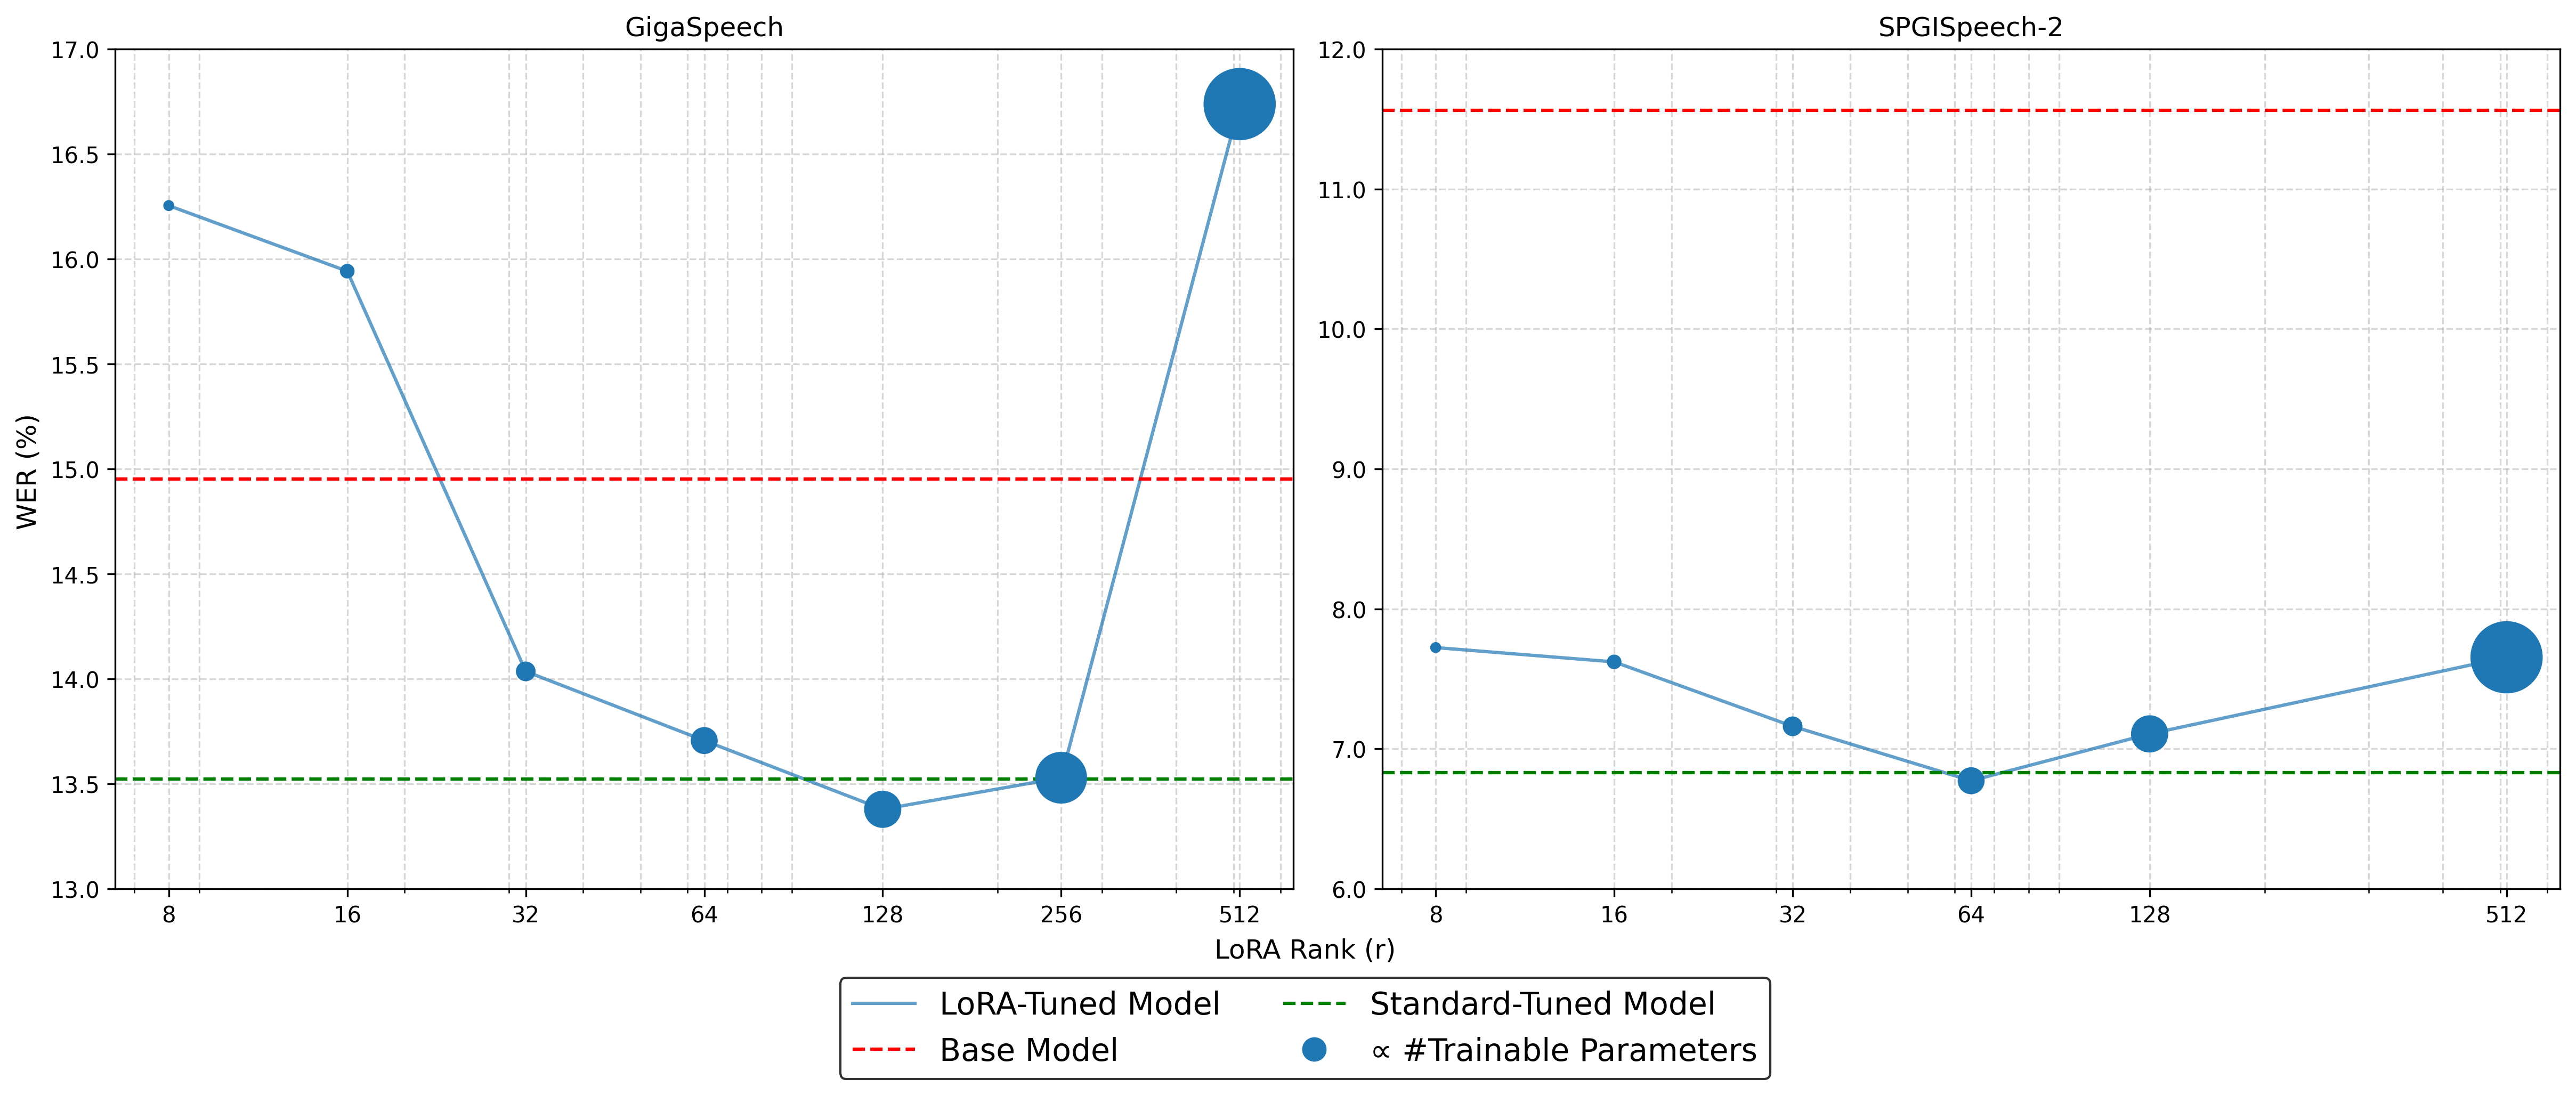

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),dpi=300)
# 1. Plot first dataset (don't add local legend, but capture the handles)
handles, labels = plot_results(df_g, ax=axes[0], title="GigaSpeech", add_legend=False)
labels = ['LoRA-Tuned Model', 'Base Model', 'Standard-Tuned Model', '∝ #Trainable Parameters']
# 2. Plot second dataset (don't add local legend)
# We assume the legend entries (colors/types) are similar enough to share
plot_results(df_s, ax=axes[1], title="SPGISpeech-2", add_legend=False)
# 3. Create ONE Global Legend on the Figure
# bbox_to_anchor centers it at bottom of figure
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,         # Turns the border on
    edgecolor='black',    # Sets the border color to black
    fancybox=True,
    fontsize=14,       # Rounded corners (False for partial square)
)
axes[0].set_ylim(13.0, 17.0)
axes[1].set_ylim(6.0, 12.0)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
# --- ADD GLOBAL LABELS ---
# valign='center' aligns it vertically in the middle height
fig.text(0.5, 0.0001, 'LoRA Rank (r)', ha='center', va='center', fontsize=12)
# rotation='vertical' makes it standard Y-axis label style
fig.text(0.001, 0.5, 'WER (%)', ha='center', va='center', rotation='vertical', fontsize=12)
# Adjust layout to make room for these new outer labels
plt.subplots_adjust(bottom=0.15, left=0.12)
plt.tight_layout()
plt.show()